### Superstore Sales Dataset

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load Dataset
df = pd.read_csv("train.csv")

In [3]:
#Dataset Inspection
print("First 10 Rows")
print(df.head(10))

print("\nLast 10 Rows")
print(df.tail(10))

First 10 Rows
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
5       6  CA-2015-115812  09/06/2015  14/06/2015  Standard Class    BH-11710   
6       7  CA-2015-115812  09/06/2015  14/06/2015  Standard Class    BH-11710   
7       8  CA-2015-115812  09/06/2015  14/06/2015  Standard Class    BH-11710   
8       9  CA-2015-115812  09/06/2015  14/06/2015  Standard Class    BH-11710   
9      10  CA-2015-115812  09/06/2015  14/06/2015  Standard Class    BH-11710   

     Customer Name    Segment        Country             City       State  \
0      Claire Gut

In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)
print("\nInfo:")
df.info()

Shape: (9800, 18)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID      

In [6]:
#Overview
overview = {
    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Numerical Columns": len(df.select_dtypes(include=np.number).columns),
    "Categorical Columns": len(df.select_dtypes(include='object').columns)
}

print(overview)

{'Rows': 9800, 'Columns': 18, 'Numerical Columns': 3, 'Categorical Columns': 15}


In [7]:
#Missing Values
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [8]:
missing_percentage = (df.isnull().sum()/len(df))*100

print(missing_percentage)

Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Date        0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
City             0.000000
State            0.000000
Postal Code      0.112245
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.000000
dtype: float64


In [9]:
duplicates = df.duplicated().sum()

print("Duplicate Rows =", duplicates)

Duplicate Rows = 0


In [10]:
#Data Cleaning
df = df.drop_duplicates()

In [11]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ","_")
)

In [12]:
print(df.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales'],
      dtype='object')


In [13]:
#Converting Data Columns
df["order_date"] = pd.to_datetime(
    df["order_date"],
    dayfirst=True
)
df["ship_date"] = pd.to_datetime(
    df["ship_date"],
    dayfirst=True
)

In [14]:
print(df["order_date"].head())

0   2017-11-08
1   2017-11-08
2   2017-06-12
3   2016-10-11
4   2016-10-11
Name: order_date, dtype: datetime64[ns]


In [16]:
#Summary 
print("\nSummary Statistics")
print(df.describe())


Summary Statistics
            row_id                     order_date  \
count  9800.000000                           9800   
mean   4900.500000  2017-05-01 05:13:51.673469440   
min       1.000000            2015-01-03 00:00:00   
25%    2450.750000            2016-05-24 00:00:00   
50%    4900.500000            2017-06-26 00:00:00   
75%    7350.250000            2018-05-15 00:00:00   
max    9800.000000            2018-12-30 00:00:00   
std    2829.160653                            NaN   

                           ship_date   postal_code         sales  
count                           9800   9789.000000   9800.000000  
mean   2017-05-05 04:17:52.653061120  55273.322403    230.769059  
min              2015-01-07 00:00:00   1040.000000      0.444000  
25%              2016-05-27 18:00:00  23223.000000     17.248000  
50%              2017-06-29 00:00:00  58103.000000     54.490000  
75%              2018-05-19 00:00:00  90008.000000    210.605000  
max              2019-01-05 00:00

In [17]:
#Value Count
print("\nCategory Count")
print(df["category"].value_counts())

print("\nRegion Count")
print(df["region"].value_counts())

print("\nSegment Count")
print(df["segment"].value_counts())


Category Count
category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

Region Count
region
West       3140
East       2785
Central    2277
South      1598
Name: count, dtype: int64

Segment Count
segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64


In [18]:
# Filtering
high_sales = df[df["sales"] > 500]
print("\nHigh Sales Records")
print(high_sales.head())


High Sales Records
    row_id        order_id order_date  ship_date       ship_mode customer_id  \
1        2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
3        4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
7        8  CA-2015-115812 2015-06-09 2015-06-14  Standard Class    BH-11710   
10      11  CA-2015-115812 2015-06-09 2015-06-14  Standard Class    BH-11710   
11      12  CA-2015-115812 2015-06-09 2015-06-14  Standard Class    BH-11710   

      customer_name   segment        country             city       state  \
1       Claire Gute  Consumer  United States        Henderson    Kentucky   
3    Sean O'Donnell  Consumer  United States  Fort Lauderdale     Florida   
7   Brosina Hoffman  Consumer  United States      Los Angeles  California   
10  Brosina Hoffman  Consumer  United States      Los Angeles  California   
11  Brosina Hoffman  Consumer  United States      Los Angeles  California   

    postal_code region       product

In [18]:
#Sorting
top_sales = df.sort_values(
    by="sales",
    ascending=False
)
print("\nTop 10 Sales")
print(top_sales.head(10))


Top 10 Sales
      row_id        order_id order_date  ship_date       ship_mode  \
2697    2698  CA-2015-145317 2015-03-18 2015-03-23  Standard Class   
6826    6827  CA-2017-118689 2017-10-02 2017-10-09  Standard Class   
8153    8154  CA-2018-140151 2018-03-23 2018-03-25     First Class   
2623    2624  CA-2018-127180 2018-10-22 2018-10-24     First Class   
4190    4191  CA-2018-166709 2018-11-17 2018-11-22  Standard Class   
9039    9040  CA-2017-117121 2017-12-17 2017-12-21  Standard Class   
4098    4099  CA-2015-116904 2015-09-23 2015-09-28  Standard Class   
4277    4278  US-2017-107440 2017-04-16 2017-04-20  Standard Class   
8488    8489  CA-2017-158841 2017-02-02 2017-02-04    Second Class   
6425    6426  CA-2017-143714 2017-05-23 2017-05-27  Standard Class   

     customer_id       customer_name      segment        country  \
2697    SM-20320         Sean Miller  Home Office  United States   
6826    TC-20980        Tamara Chand    Corporate  United States   
8153    RB-

In [19]:
# Grouping & Aggregation
category_summary = df.groupby("category").agg(
    total_sales=("sales","sum"),
    average_sales=("sales","mean"),
    total_orders=("sales","count")
)
print("\nCategory Summary")
print(category_summary)


Category Summary
                 total_sales  average_sales  total_orders
category                                                 
Furniture        728658.5757     350.653790          2078
Office Supplies  705422.3340     119.381001          5909
Technology       827455.8730     456.401474          1813


In [20]:
# Feature Engineering
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["day_name"] = df["order_date"].dt.day_name()

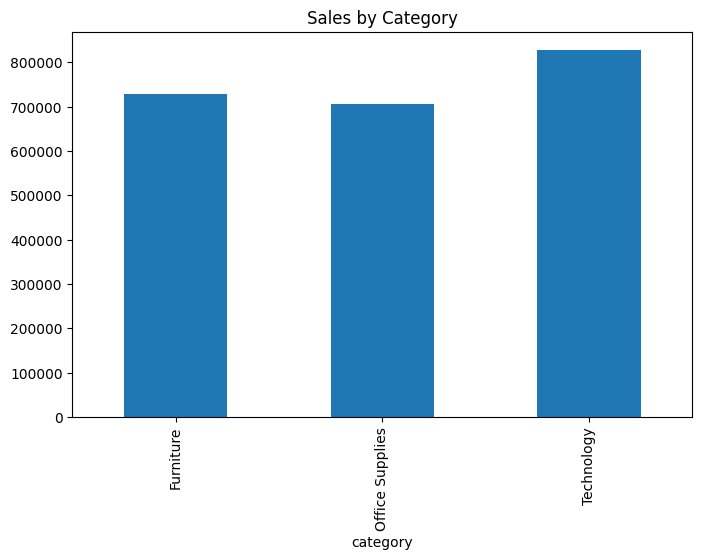

In [25]:
# Visualization
plt.figure(figsize=(8,5))
df.groupby("category")["sales"].sum().plot(
    kind="bar"
)
plt.title("Sales by Category")
plt.show()

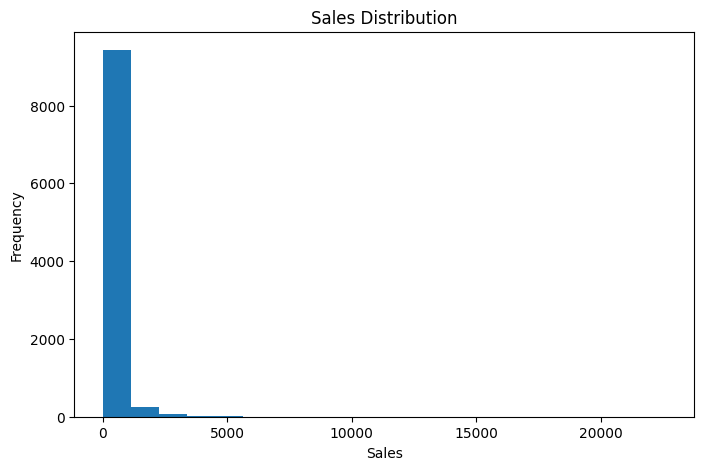

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df["sales"], bins=20)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()


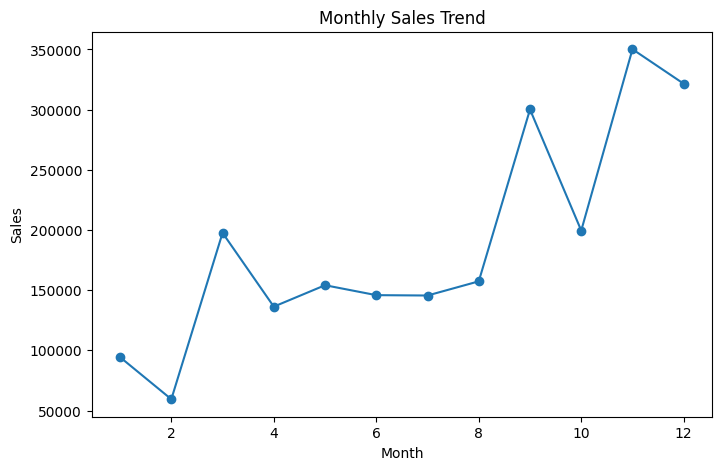

In [22]:
monthly_sales = df.groupby("month")["sales"].sum()
plt.figure(figsize=(8,5))
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

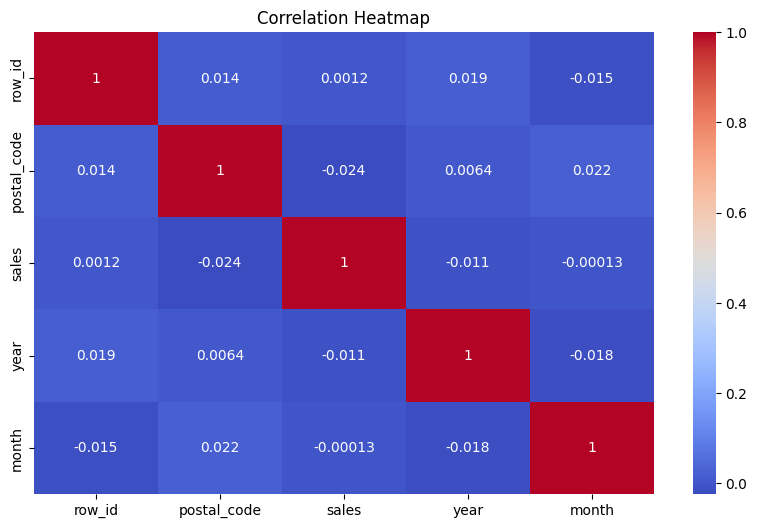

In [23]:
correlation_matrix = (
    df.select_dtypes(include="number")
    .corr()
)
plt.figure(figsize=(10,6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [24]:
df.to_csv(
    "cleaned_dataset.csv",
    index=False
)
category_summary.to_csv(
    "category_summary.csv"
)
print("Analysis Completed Successfully")

Analysis Completed Successfully
